In [ ]:
import ast
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.multiclass import OneVsRestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import f1_score, hamming_loss, accuracy_score

In [ ]:
!pip install scikit-multilearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.4/89.4 kB 2.1 MB/s eta 0:00:00


In [ ]:
df_encoded = pd.read_csv("/content/df_encoded.csv")

In [ ]:
df_encoded_nan= pd.read_csv("/content/df_encoded_nan.csv")

In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106871 entries, 0 to 106870
Data columns (total 61 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   originalTitle           106871 non-null  object 
 1   rating                  106871 non-null  int64  
 2   startYear               106871 non-null  int64  
 3   runtimeMinutes          88027 non-null   float64
 4   numVotes                106871 non-null  int64  
 5   totalCredits            106871 non-null  int64  
 6   criticReviewsTotal      106871 non-null  int64  
 7   numRegions              106871 non-null  int64  
 8   userReviewsTotal        106871 non-null  int64  
 9   companiesNumber         106871 non-null  int64  
 10  averageRating           106871 non-null  float64
 11  externalLinks           106871 non-null  int64  
 12  writerCredits           106871 non-null  int64  
 13  directorsCredits        106871 non-null  int64  
 14  quotesTotal         

In [ ]:
df_encoded["genres_Film-Noir"].value_counts()

,count
genres_Film-Noir,
0,106716
1,155


#Scaling+Classification

In [ ]:
# Divisione train/test
X = df_encoded.drop(columns= [ 'originalTitle','runtimeMinutes', "genres_Film-Noir", "from_Africa",
    "from_Asia",
    "from_Europe",
    "from_North America",
    "from_Oceania",
    "from_South America" ])
y = df_encoded[["from_Africa",
    "from_Asia",
    "from_Europe",
    "from_North America",
    "from_Oceania",
    "from_South America"]]

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

features_to_scale = [
    'rating', 'startYear', 'numVotes', 'totalCredits',
    'criticReviewsTotal', 'numRegions', 'userReviewsTotal', 'companiesNumber',
    'averageRating', 'externalLinks', 'writerCredits', 'directorsCredits',
    'quotesTotal', 'totalMedia', 'totalNominations'
]

# Tutte le altre colonne (che non devono essere scalate)
features_not_scaled = [col for col in X.columns if col not in features_to_scale]


In [ ]:
# Inizializza lo scaler
scaler = StandardScaler()

# Applica lo scaling solo sulle colonne selezionate
X_scaled_part = pd.DataFrame(
    scaler.fit_transform(X[features_to_scale]),
    columns=features_to_scale,
    index=X.index
)

# Prendi le altre colonne così come sono
X_not_scaled_part = X[features_not_scaled]


In [ ]:
X_prepared = pd.concat([X_scaled_part, X_not_scaled_part], axis=1)

# Ordina le colonne per sicurezza (opzionale)
X_prepared = X_prepared[X.columns]  # per mantenere l'ordine originale


In [ ]:
X_prepared

,rating,startYear,numVotes,totalCredits,criticReviewsTotal,numRegions,userReviewsTotal,companiesNumber,averageRating,externalLinks,...,titleType_movie,titleType_short,titleType_tvEpisode,titleType_tvMiniSeries,titleType_tvMovie,titleType_tvSeries,titleType_tvShort,titleType_tvSpecial,titleType_video,titleType_videoGame
0,-0.548351,-3.769691,0.025332,-0.323723,0.000470,0.570961,0.106440,-0.178924,-0.748858,0.090437,...,0,1,0,0,0,0,0,0,0,0
1,-1.273067,-3.846729,-0.055280,-0.334910,-0.182247,0.402212,-0.084790,-0.325389,-0.971201,-0.168430,...,0,1,0,0,0,0,0,0,0,0
2,-1.273067,-3.769691,-0.054773,-0.340503,-0.182247,0.233464,-0.097539,-0.276567,-1.267659,-0.125286,...,0,1,0,0,0,0,0,0,0,0
3,-1.273067,-3.769691,0.031592,-0.323723,-0.060436,0.402212,0.157435,-0.032458,-0.971201,-0.038997,...,0,1,0,0,0,0,0,0,0,0
4,0.176366,-3.692653,0.491668,-0.284568,0.792246,2.933440,0.743876,-0.081280,0.511087,0.608170,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106866,0.901083,0.929626,-0.061455,-0.245413,-0.182247,-0.441531,-0.097539,-0.227746,1.178117,-0.254719,...,0,0,0,0,0,1,0,0,0,0
106867,-0.548351,1.045183,-0.062386,-0.284568,-0.182247,-0.441531,-0.084790,-0.276567,-0.674743,-0.254719,...,1,0,0,0,0,0,0,0,0,0
106868,-0.548351,1.006664,-0.062343,-0.340503,-0.182247,-0.441531,-0.072041,-0.227746,-0.526515,-0.168430,...,0,0,0,0,0,0,0,0,1,0
106869,0.176366,0.043689,-0.062555,-0.284568,-0.182247,-0.441531,-0.097539,-0.227746,0.214629,-0.254719,...,1,0,0,0,0,0,0,0,0,0


In [ ]:
X_prepared.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106871 entries, 0 to 106870
Data columns (total 52 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   rating                  106871 non-null  float64
 1   startYear               106871 non-null  float64
 2   numVotes                106871 non-null  float64
 3   totalCredits            106871 non-null  float64
 4   criticReviewsTotal      106871 non-null  float64
 5   numRegions              106871 non-null  float64
 6   userReviewsTotal        106871 non-null  float64
 7   companiesNumber         106871 non-null  float64
 8   averageRating           106871 non-null  float64
 9   externalLinks           106871 non-null  float64
 10  writerCredits           106871 non-null  float64
 11  directorsCredits        106871 non-null  float64
 12  quotesTotal             106871 non-null  float64
 13  totalMedia              106871 non-null  float64
 14  totalNominations    

In [ ]:
from skmultilearn.model_selection import iterative_train_test_split

# Converti in NumPy array
X_np = X_prepared.values
y_np = y.values

# Split stratificato multilabel
X_train_np, y_train_np, X_test_np, y_test_np = iterative_train_test_split(
    X_np, y_np, test_size=0.3
)

#RandomForestClassifier con GridSearch e Kfold

In [ ]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import f1_score

# Funzione per trovare la soglia ottimale per una label
def find_best_threshold(y_true, y_proba):
    thresholds = np.arange(0.0, 1.01, 0.01)
    f1_scores = []
    for thresh in thresholds:
        y_pred = (y_proba >= thresh).astype(int)
        f1_scores.append(f1_score(y_true, y_pred))
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx], f1_scores[best_idx]

# Configurazione
kf = KFold(n_splits=5, shuffle=True, random_state=42)
region_labels = ["from_Africa", "from_Asia", "from_Europe",
                 "from_North America", "from_Oceania", "from_South America"]

# Lista per salvare soglie trovate in ogni fold
thresholds_per_fold = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_np), 1):
    X_train, X_val = X_np[train_idx], X_np[val_idx]
    y_train, y_val = y_np[train_idx], y_np[val_idx]

    rf = RandomForestClassifier(
        bootstrap=True,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42
    )
    model = MultiOutputClassifier(rf)
    model.fit(X_train, y_train)

    # Calcola probabilità predette sul validation set
    y_proba = np.column_stack([
        est.predict_proba(X_val)[:, 1] for est in model.estimators_
    ])

    fold_thresholds = []
    print(f"\nFold {fold}:")
    for i, label in enumerate(region_labels):
        best_thresh, best_f1 = find_best_threshold(y_val[:, i], y_proba[:, i])
        fold_thresholds.append(best_thresh)
        print(f"  {label}: soglia ottimale = {best_thresh:.2f}, F1 = {best_f1:.4f}")

    thresholds_per_fold.append(fold_thresholds)

# Media soglie su tutti i fold
mean_thresholds = np.mean(thresholds_per_fold, axis=0)

print("\nSoglie medie ottimali per ogni label:")
for label, thresh in zip(region_labels, mean_thresholds):
    print(f"  {label}: {thresh:.2f}")



Fold 1:
  from_Africa: soglia ottimale = 0.18, F1 = 0.2817
  from_Asia: soglia ottimale = 0.30, F1 = 0.7052
  from_Europe: soglia ottimale = 0.37, F1 = 0.7270
  from_North America: soglia ottimale = 0.46, F1 = 0.8195
  from_Oceania: soglia ottimale = 0.23, F1 = 0.5192
  from_South America: soglia ottimale = 0.19, F1 = 0.2654

Fold 2:
  from_Africa: soglia ottimale = 0.20, F1 = 0.2571
  from_Asia: soglia ottimale = 0.34, F1 = 0.6984
  from_Europe: soglia ottimale = 0.38, F1 = 0.7219
  from_North America: soglia ottimale = 0.43, F1 = 0.8177
  from_Oceania: soglia ottimale = 0.25, F1 = 0.4672
  from_South America: soglia ottimale = 0.17, F1 = 0.2728

Fold 3:
  from_Africa: soglia ottimale = 0.13, F1 = 0.2561
  from_Asia: soglia ottimale = 0.32, F1 = 0.6993
  from_Europe: soglia ottimale = 0.39, F1 = 0.7304
  from_North America: soglia ottimale = 0.44, F1 = 0.8159
  from_Oceania: soglia ottimale = 0.22, F1 = 0.5263
  from_South America: soglia ottimale = 0.12, F1 = 0.2947

Fold 4:
  from_

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
import numpy as np

# Soglie ottimali per ogni etichetta
optimal_thresh = {
    "from_Africa": 0.16,
    "from_Asia": 0.33,
    "from_Europe": 0.38,
    "from_North America": 0.44,
    "from_Oceania": 0.22,
    "from_South America": 0.15
}

# Ordine delle etichette (devono corrispondere all'ordine in y_np)
region_labels = ["from_Africa", "from_Asia", "from_Europe",
                 "from_North America", "from_Oceania", "from_South America"]

# 5-fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
f1_scores = []

# Accumula tutti i veri valori e le predizioni
y_true_all = []
y_pred_all = []

for fold, (train_index, val_index) in enumerate(kf.split(X_np), 1):
    X_train, X_val = X_np[train_index], X_np[val_index]
    y_train, y_val = y_np[train_index], y_np[val_index]

    rf = RandomForestClassifier(
        bootstrap=True,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42
    )
    model = MultiOutputClassifier(rf)
    model.fit(X_train, y_train)

    # Ottieni le probabilità predette per ogni label
    y_proba = np.column_stack([
        est.predict_proba(X_val)[:, 1]
        for est in model.estimators_
    ])

    # Applica le soglie ottimali
    y_pred = np.zeros_like(y_proba, dtype=int)
    for i, label in enumerate(region_labels):
        thresh = optimal_thresh[label]
        y_pred[:, i] = (y_proba[:, i] >= thresh).astype(int)

    # Valutazione F1 macro
    f1 = f1_score(y_val, y_pred, average='macro')
    f1_scores.append(f1)
    print(f"Fold {fold} - F1 macro score: {f1:.4f}")

    y_true_all.append(y_val)
    y_pred_all.append(y_pred)

# Risultati aggregati
print(f"\nMedia F1 macro score su {kf.n_splits} folds: {np.mean(f1_scores):.4f}")

y_true_all = np.vstack(y_true_all)
y_pred_all = np.vstack(y_pred_all)

print("\nClassification Report aggregato:")
print(classification_report(y_true_all, y_pred_all, target_names=region_labels, zero_division=0))


Fold 1 - F1 macro score: 0.5491
Fold 2 - F1 macro score: 0.5444
Fold 3 - F1 macro score: 0.5525
Fold 4 - F1 macro score: 0.5396
Fold 5 - F1 macro score: 0.5457

Media F1 macro score su 5 folds: 0.5463

Classification Report aggregato:
                    precision    recall  f1-score   support

       from_Africa       0.44      0.19      0.27      1028
         from_Asia       0.68      0.70      0.69     15957
       from_Europe       0.68      0.78      0.73     37165
from_North America       0.79      0.85      0.82     52035
      from_Oceania       0.90      0.34      0.50      2325
from_South America       0.32      0.25      0.28      2457

         micro avg       0.73      0.77      0.75    110967
         macro avg       0.63      0.52      0.55    110967
      weighted avg       0.73      0.77      0.75    110967
       samples avg       0.74      0.78      0.75    110967




Confusion Matrix per from_Africa:
[[105591    252]
 [   832    196]]


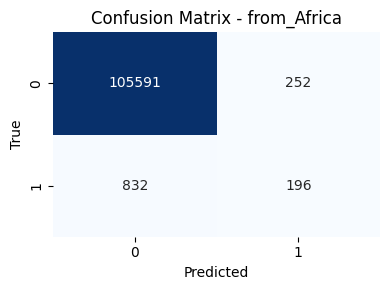


Confusion Matrix per from_Asia:
[[85739  5175]
 [ 4762 11195]]


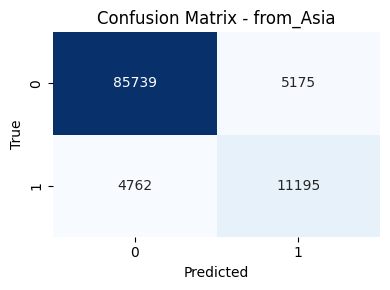


Confusion Matrix per from_Europe:
[[55885 13821]
 [ 8169 28996]]


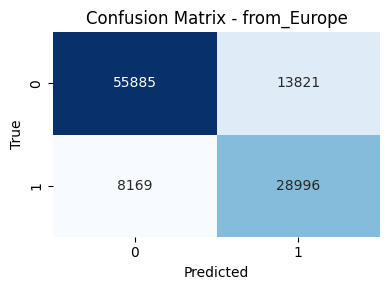


Confusion Matrix per from_North America:
[[43473 11363]
 [ 8015 44020]]


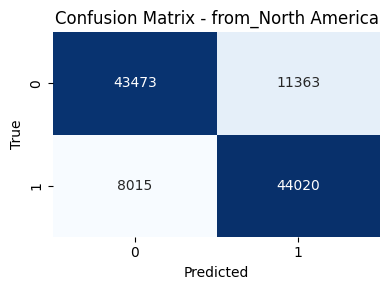


Confusion Matrix per from_Oceania:
[[104457     89]
 [  1526    799]]


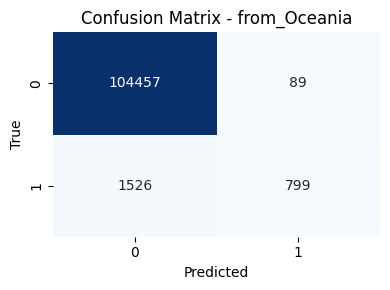


Confusion Matrix per from_South America:
[[103091   1323]
 [  1846    611]]


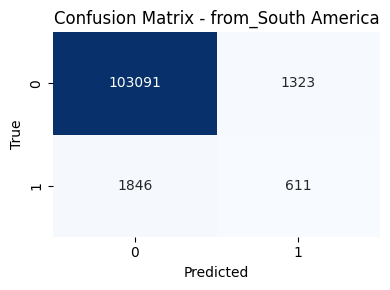

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizza Confusion Matrix per ogni etichetta
for i, label in enumerate(region_labels):
    cm = confusion_matrix(y_true_all[:, i], y_pred_all[:, i])

    print(f"\nConfusion Matrix per {label}:\n{cm}")

    # Plot con Seaborn
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {label}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()


### predizione vera e propria

In [ ]:
# 1. Seleziona le righe con NaN nel target
# Supponiamo che y abbia queste colonne:
target_cols = y.columns.tolist()

# Righe dove almeno un target è NaN
df_missing = df_encoded_nan[df_encoded_nan[target_cols].isna().any(axis=1)].copy()

# 2. Ottieni solo le feature (X) da queste righe
X_missing = df_missing[X.columns].values  # Assicurati che X.columns siano usate

# 3. Predici i valori mancanti
y_pred_missing = model.predict(X_missing)

# 4. Inserisci le predizioni nelle colonne corrispondenti
df_missing.loc[df_missing.index, target_cols] = y_pred_missing

# 5. Ora df_new ha i NaN riempiti con le predizioni del modello


In [ ]:
df_encoded_nan.shape

(39461, 61)

In [ ]:
df_missing

,originalTitle,rating,startYear,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,numRegions,userReviewsTotal,companiesNumber,...,titleType_tvShort,titleType_tvSpecial,titleType_video,titleType_videoGame,from_Africa,from_Asia,from_Europe,from_North America,from_Oceania,from_South America
0,'Round the World in 80 Days,5,1914,NaN,41,2,0,2,1,2,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,The Greatest Man in the World,8,1958,57.0,26,32,0,0,4,2,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0
2,A Free Agent,7,1964,60.0,12,35,0,0,0,4,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,A Guide to Armageddon,9,1982,NaN,76,9,0,0,4,0,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0
4,A félelem ára,6,1993,60.0,6,94,0,0,0,0,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39456,Women Take Center Stage,6,2019,NaN,12,32,0,0,0,0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
39457,Horrid Henry and the Christening Crisis,7,2011,10.0,9,15,0,0,0,0,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0
39458,A lenda do soprador de vidro,9,2019,NaN,9,33,0,0,0,0,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0
39459,Chi Nhung,7,1970,66.0,15,11,0,8,0,1,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df_missing["from_South America"].value_counts()

,count
from_South America,
0.0,39461


### controllo sui record che sono rimasti a 0 dopo la classificazione

In [ ]:
# Colonne regionali da controllare
region_cols = [
    "from_Africa", "from_Asia", "from_Europe",
    "from_North America", "from_Oceania", "from_South America"
]

# Seleziona righe dove tutte le colonne 'from_*' sono 0
df_zero_regions = df_missing[df_missing[region_cols].sum(axis=1) == 0]

# Mostra le prime righe trovate
print(f"Numero di righe con tutte le regioni a 0: {len(df_zero_regions)}")
df_zero_regions

Numero di righe con tutte le regioni a 0: 3907


,originalTitle,rating,startYear,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,numRegions,userReviewsTotal,companiesNumber,...,titleType_tvSpecial,titleType_video,titleType_videoGame,from_Africa,from_Asia,from_Europe,from_North America,from_Oceania,from_South America,genres_Film-Noir
0,'Round the World in 80 Days,5,1914,NaN,41,2,0,2,1,2,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,A Free Agent,7,1964,60.0,12,35,0,0,0,4,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0
12,Grading on a Curve,7,1995,NaN,10,16,0,0,0,1,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0
19,Absolute Zero,6,2001,NaN,34,0,0,0,0,0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0
37,La danseuse du Gai-moulin,7,1981,NaN,15,35,0,0,0,1,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39410,Episode #2.1,7,1999,NaN,5,45,0,7,0,0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0
39436,It's Kind of a Phone-y Story,8,2019,43.0,25,37,0,0,0,1,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0
39439,Die Liste,7,2019,45.0,29,159,0,0,0,29,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0
39456,Women Take Center Stage,6,2019,NaN,12,32,0,0,0,0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [ ]:
df_zero_regions.isna().sum()

,0
originalTitle,0
rating,0
startYear,0
runtimeMinutes,4189
numVotes,0
totalCredits,0
criticReviewsTotal,0
numRegions,0
userReviewsTotal,0
companiesNumber,0


In [ ]:
import numpy as np

region_labels = ["from_Africa", "from_Asia", "from_Europe",
                 "from_North America", "from_Oceania", "from_South America"]

# 1. Trova le righe con tutte predizioni a 0
all_zero_mask = (df_missing[region_labels].sum(axis=1) == 0)

# 2. Ottieni le feature di queste sole righe
X_zero = df_missing.loc[all_zero_mask, X.columns].values

# 3. Ottieni le probabilità predette solo per queste righe
y_proba_zero = np.column_stack([
    est.predict_proba(X_zero)[:, 1] for est in model.estimators_
])

# 4. Trova l’etichetta con probabilità più alta per ciascuna riga
max_indices = np.argmax(y_proba_zero, axis=1)

# 5. Inserisci un 1 nella colonna corrispondente
for row_idx, label_idx in zip(df_missing.loc[all_zero_mask].index, max_indices):
    df_missing.loc[row_idx, region_labels[label_idx]] = 1


In [ ]:
# Colonne regionali da controllare
region_cols = [
    "from_Africa", "from_Asia", "from_Europe",
    "from_North America", "from_Oceania", "from_South America"
]

# Seleziona righe dove tutte le colonne 'from_*' sono 0
df_zero_regions = df_missing[df_missing[region_cols].sum(axis=1) == 0]

# Mostra le prime righe trovate
print(f"Numero di righe con tutte le regioni a 0: {len(df_zero_regions)}")
df_zero_regions

Numero di righe con tutte le regioni a 0: 0


,originalTitle,rating,startYear,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,numRegions,userReviewsTotal,companiesNumber,...,titleType_tvSpecial,titleType_video,titleType_videoGame,from_Africa,from_Asia,from_Europe,from_North America,from_Oceania,from_South America,genres_Film-Noir


### creazione df finale

In [ ]:
df_finale = pd.concat([df_encoded, df_missing], axis=0)

In [ ]:
num_duplicati = df_encoded_nan.duplicated().sum()
print(f"Righe duplicate: {num_duplicati}")


Righe duplicate: 0


In [ ]:
df_finale.duplicated().sum()

np.int64(0)

In [ ]:
righe_comuni = pd.merge(df_encoded, df_encoded_nan, how='inner')
print(f"Righe in comune (per contenuto): {len(righe_comuni)}")


Righe in comune (per contenuto): 0


In [ ]:
df_missing.shape

(39461, 61)

In [ ]:
df_missing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39461 entries, 0 to 39460
Data columns (total 60 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   originalTitle           39461 non-null  object 
 1   rating                  39461 non-null  int64  
 2   startYear               39461 non-null  int64  
 3   runtimeMinutes          19800 non-null  float64
 4   numVotes                39461 non-null  int64  
 5   totalCredits            39461 non-null  int64  
 6   criticReviewsTotal      39461 non-null  int64  
 7   numRegions              39461 non-null  int64  
 8   userReviewsTotal        39461 non-null  int64  
 9   companiesNumber         39461 non-null  int64  
 10  averageRating           39461 non-null  float64
 11  externalLinks           39461 non-null  int64  
 12  writerCredits           39461 non-null  int64  
 13  directorsCredits        39461 non-null  int64  
 14  quotesTotal             39461 non-null

In [ ]:
duplicati = df_encoded_nan[df_encoded_nan.duplicated()]
duplicati

,originalTitle,rating,startYear,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,numRegions,userReviewsTotal,companiesNumber,...,titleType_tvSpecial,titleType_video,titleType_videoGame,from_Africa,from_Asia,from_Europe,from_North America,from_Oceania,from_South America,genres_Film-Noir


In [ ]:
dfdf_finale[df_finale.duplicated(subset=[col for col in df_finale.columns if col not in ['originalTitle']], keep=False)]


,originalTitle,rating,startYear,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,numRegions,userReviewsTotal,companiesNumber,...,titleType_movie,titleType_short,titleType_tvEpisode,titleType_tvMiniSeries,titleType_tvMovie,titleType_tvSeries,titleType_tvShort,titleType_tvSpecial,titleType_video,titleType_videoGame
38047,Am Wasserfall,4,1897,NaN,14,1,0,1,0,1,...,0,1,0,0,0,0,0,0,0,0
43591,The Fear: Part 2,8,1988,NaN,9,66,0,1,0,2,...,0,0,1,0,0,0,0,0,0,0
45401,Home Sweet Home,9,1990,NaN,16,85,0,1,0,3,...,0,0,1,0,0,0,0,0,0,0
45410,My Love Always,9,1990,NaN,16,85,0,1,0,3,...,0,0,1,0,0,0,0,0,0,0
52454,Episode #39.5,7,1998,NaN,8,6,0,7,0,1,...,0,0,1,0,0,0,0,0,0,0
52456,Episode #39.8,7,1998,NaN,8,6,0,7,0,1,...,0,0,1,0,0,0,0,0,0,0
52957,Bed and Board,8,1988,NaN,9,66,0,1,0,2,...,0,0,1,0,0,0,0,0,0,0
53749,Passé compliqué,7,1994,30.0,7,12,0,1,0,5,...,0,0,1,0,0,0,0,0,0,0
54281,Essai non concluant,7,1994,30.0,7,12,0,1,0,5,...,0,0,1,0,0,0,0,0,0,0
55195,Episode #1.1006,7,1970,23.0,21,31,0,7,1,7,...,0,0,1,0,0,0,0,0,0,0


In [ ]:
df_missing["from_Africa"].value_counts()

,count
from_Africa,
0.0,39461


In [ ]:
df_finale.to_csv("df_completo.csv", index=False)


In [ ]:
from google.colab import files
files.download("df_completo.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>